Configured spark to access the azure storage

In [0]:
# Set your storage account details
storage_account = "nyctaxistorage2016"
container = "raw-data"
file_path = "yellow_tripdata_2016-03.csv"

# Your storage account key (regenerate if needed)
account_key = "vIIu5aJrVdEkS521dVC59WfwdJV4Gz0BN4f/ccJk41RYnDCsnVGzs2f/qFBoDESKGBLcWV0cIXQT+AStH5VwZA=="

# Set Spark configuration – this works in standard compute
spark.conf.set(f"fs.azure.account.key.{storage_account}.blob.core.windows.net", account_key)

print("Storage access configured successfully")

Storage access configured successfully


reading the csv file

In [0]:
# Build the URL (using wasbs:// for Blob Storage)
url = f"wasbs://{container}@{storage_account}.blob.core.windows.net/{file_path}"

# Read CSV with header and schema inference
taxi_raw = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(url)

# Display basic info
print(f"Total records loaded: {taxi_raw.count():,}")
taxi_raw.printSchema()
display(taxi_raw.limit(10))

Total records loaded: 12,210,952
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)



VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1,2016-03-01T00:00:00Z,2016-03-01T00:07:55Z,1,2.5,-73.97674560546875,40.76515197753906,1,N,-74.00426483154297,40.74612808227539,1,9.0,0.5,0.5,2.05,0.0,0.3,12.35
1,2016-03-01T00:00:00Z,2016-03-01T00:11:06Z,1,2.9,-73.98348236083984,40.76792526245117,1,N,-74.00594329833984,40.7331657409668,1,11.0,0.5,0.5,3.05,0.0,0.3,15.35
2,2016-03-01T00:00:00Z,2016-03-01T00:31:06Z,2,19.98,-73.78202056884766,40.64480972290039,1,N,-73.97454071044922,40.6757698059082,1,54.5,0.5,0.5,8.0,0.0,0.3,63.8
2,2016-03-01T00:00:00Z,2016-03-01T00:00:00Z,3,10.78,-73.86341857910156,40.769813537597656,1,N,-73.96965026855469,40.75776672363281,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
2,2016-03-01T00:00:00Z,2016-03-01T00:00:00Z,5,30.43,-73.97174072265625,40.79218292236328,3,N,-74.17716979980469,40.69505310058594,1,98.0,0.0,0.0,0.0,15.5,0.3,113.8
2,2016-03-01T00:00:00Z,2016-03-01T00:00:00Z,5,5.92,-74.01719665527344,40.70538330078125,1,N,-73.97807312011719,40.75578689575195,1,23.5,1.0,0.5,5.06,0.0,0.3,30.36
2,2016-03-01T00:00:00Z,2016-03-01T00:00:00Z,6,5.72,-73.99458312988281,40.727848052978516,1,N,0.0,0.0,2,23.0,0.5,0.5,0.0,0.0,0.3,24.3
1,2016-03-01T00:00:01Z,2016-03-01T00:16:04Z,1,6.2,-73.78877258300781,40.64775848388672,1,N,-73.82920837402344,40.712345123291016,3,20.5,0.5,0.5,0.0,0.0,0.3,21.8
1,2016-03-01T00:00:01Z,2016-03-01T00:05:00Z,1,0.7,-73.95822143554688,40.76464080810547,1,N,-73.9678955078125,40.762901306152344,1,5.5,0.5,0.5,2.0,0.0,0.3,8.8
2,2016-03-01T00:00:01Z,2016-03-01T00:24:06Z,3,7.18,-73.98577880859375,40.74119186401367,1,N,-73.94635009765625,40.79787826538086,1,23.5,0.5,0.5,3.2,0.0,0.3,28.0


Data cleaning (remove nulls, outliers, invalid coordinates)

In [0]:
from pyspark.sql.functions import col, hour, dayofweek, month, when

# Remove rows with null pickup/dropoff timestamps
taxi_clean = taxi_raw.filter(col("tpep_pickup_datetime").isNotNull()) \
                 .filter(col("tpep_dropoff_datetime").isNotNull())

# Remove unrealistic trips
taxi_clean = taxi_clean.filter(col("trip_distance") > 0) \
                   .filter(col("trip_distance") <= 100) \
                   .filter(col("fare_amount") > 0) \
                   .filter(col("fare_amount") <= 500)

# Filter valid NYC coordinates (approximate bounding box)
taxi_clean = taxi_clean.filter((col("pickup_longitude") > -74.05) & (col("pickup_longitude") < -73.75)) \
                   .filter((col("pickup_latitude") > 40.60) & (col("pickup_latitude") < 40.90))

# Fill missing passenger_count with 1
taxi_clean = taxi_clean.fillna({"passenger_count": 1})

print(f"Records after cleaning: {taxi_clean.count():,}")

Records after cleaning: 11,960,213


Feature engineering (add derived columns)

In [0]:
# Add time-based and trip-based columns
taxi_enriched = taxi_clean \
    .withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
    .withColumn("pickup_day", dayofweek("tpep_pickup_datetime")) \
    .withColumn("pickup_month", month("tpep_pickup_datetime")) \
    .withColumn("trip_duration_minutes", 
                (col("tpep_dropoff_datetime").cast("long") - 
                 col("tpep_pickup_datetime").cast("long")) / 60) \
    .withColumn("speed_mph", 
                when(col("trip_duration_minutes") > 0, 
                     col("trip_distance") / (col("trip_duration_minutes") / 60))
                .otherwise(0)) \
    .withColumn("tip_percentage", 
                when(col("total_amount") > 0, 
                     (col("tip_amount") / col("total_amount")) * 100)
                .otherwise(0))

# Remove trips with extreme duration or speed
taxi_final = taxi_enriched.filter(col("trip_duration_minutes") >= 1) \
                      .filter(col("trip_duration_minutes") <= 180) \
                      .filter(col("speed_mph") <= 60)

print(f"Final records after feature engineering: {taxi_final.count():,}")
print(f"Removed records: {df_raw.count() - taxi_final.count():,} ({(taxi_raw.count() - taxi_final.count())/taxi_raw.count()*100:.1f}%)")

Final records after feature engineering: 11,904,859
Removed records: 306,093 (2.5%)


Displaying samples of enriched data

In [0]:
display(taxi_final.select("tpep_pickup_datetime", "trip_distance", "fare_amount", 
                        "pickup_hour", "trip_duration_minutes", "speed_mph", "tip_percentage").limit(10))

tpep_pickup_datetime,trip_distance,fare_amount,pickup_hour,trip_duration_minutes,speed_mph,tip_percentage
2016-03-01T00:00:00Z,2.5,9.0,0,7.916666666666667,18.94736842105263,16.59919028340081
2016-03-01T00:00:00Z,2.9,11.0,0,11.1,15.675675675675675,19.86970684039088
2016-03-01T00:00:00Z,19.98,54.5,0,31.1,38.54662379421222,12.539184952978058
2016-03-01T00:00:01Z,6.2,20.5,0,16.05,23.177570093457945,0.0
2016-03-01T00:00:01Z,0.7,5.5,0,4.983333333333333,8.428093645484948,22.727272727272727
2016-03-01T00:00:01Z,7.18,23.5,0,24.083333333333332,17.887889273356404,11.428571428571429
2016-03-01T00:00:01Z,0.54,4.0,0,2.033333333333333,15.9344262295082,0.0
2016-03-01T00:00:02Z,1.7,8.0,0,7.783333333333333,13.104925053533192,0.0
2016-03-01T00:00:02Z,1.1,5.5,0,3.05,21.639344262295086,24.444444444444446
2016-03-01T00:00:02Z,2.1,9.0,0,9.5,13.263157894736842,16.666666666666668


Save as Delta table for later analysis

In [0]:
output_path = "wasbs://processed-data@nyctaxistorage2016.blob.core.windows.net/silver/nyc_taxi_delta"
taxi_final.write.format("delta").mode("overwrite").partitionBy("pickup_month").save(output_path)
print(f"Saved cleaned data to {output_path}")

Saved cleaned data to wasbs://processed-data@nyctaxistorage2016.blob.core.windows.net/silver/nyc_taxi_delta


#Cloud‑Based Analytics Solution

Query 1: Peak hour analysis – which hours have the most trips and highest revenue?

In [0]:
from pyspark.sql.functions import count, avg, sum as spark_sum, round

peak_hours = taxi_final.groupBy("pickup_hour").agg(
    count("*").alias("total_trips"),
    round(avg("fare_amount"), 2).alias("avg_fare"),
    round(spark_sum("total_amount"), 2).alias("total_revenue")
).orderBy("total_trips", ascending=False)

display(peak_hours)

pickup_hour,total_trips,avg_fare,total_revenue
19,754522,11.74,1.156262547E7
18,750587,12.05,1.176581871E7
20,712292,12.15,1.107713424E7
21,700474,12.53,1.118437856E7
22,659351,13.11,1.095739297E7
17,633731,12.86,1.054394327E7
14,602143,13.31,9815950.15
15,584595,13.31,9561391.7
13,576370,12.78,9018692.65
12,575112,12.49,8784077.93


Query 2: Tip percentage by day of week – driver earnings insight

In [0]:
tip_by_day = taxi_final.groupBy("pickup_day").agg(
    round(avg("tip_percentage"), 2).alias("avg_tip_pct"),
    round(avg("trip_distance"), 2).alias("avg_distance"),
    count("*").alias("trip_count")
).orderBy("pickup_day")

display(tip_by_day)

pickup_day,avg_tip_pct,avg_distance,trip_count
1,9.87,3.26,1446549
2,10.27,3.04,1386593
3,10.58,2.9,1828675
4,10.64,2.91,1910166
5,10.58,2.98,1985622
6,10.28,2.95,1653864
7,9.77,2.83,1693390


Query 3: Average fare and distance by passenger count

In [0]:
passenger_analysis = taxi_final.groupBy("passenger_count").agg(
    round(avg("fare_amount"), 2).alias("avg_fare"),
    round(avg("trip_distance"), 2).alias("avg_distance"),
    count("*").alias("trip_count")
).orderBy("passenger_count")

display(passenger_analysis)

passenger_count,avg_fare,avg_distance,trip_count
0,29.43,7.15,80
1,12.53,2.91,8456694
2,13.3,3.17,1692381
3,13.03,3.06,488623
4,13.35,3.16,234220
5,12.87,3.07,634101
6,12.66,2.99,398730
7,53.75,9.0,10
8,75.25,10.23,12
9,64.88,11.1,8


 Machine Learning Algorithm

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

# Select features and label
feature_cols = ["passenger_count", "trip_distance", "pickup_hour", "trip_duration_minutes"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Create a small sample for faster training (optional, but fine for 1GB data)
taxi_ml = taxi_final.select("fare_amount", *feature_cols).na.drop()

# Split data
train_data, test_data = taxi_ml.randomSplit([0.8, 0.2], seed=42)

# Build model
lr = LinearRegression(featuresCol="features", labelCol="fare_amount")
pipeline = Pipeline(stages=[assembler, lr])

# Train
model = pipeline.fit(train_data)

# Predict and evaluate
predictions = model.transform(test_data)
evaluator = RegressionEvaluator(labelCol="fare_amount", metricName="rmse")
rmse = evaluator.evaluate(predictions)
r2 = evaluator.setMetricName("r2").evaluate(predictions)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Show feature coefficients (optional)
coefficients = model.stages[-1].coefficients
for name, coef in zip(feature_cols, coefficients):
    print(f"{name}: {coef:.4f}")

RMSE: 2.40
R² Score: 0.9466
passenger_count: -0.0153
trip_distance: 2.1050
pickup_hour: -0.0010
trip_duration_minutes: 0.2849


Save the trained ML model (for reproducibility)

In [0]:
# Save the model to Azure Blob Storage or DBFS
model_path = "/models/nyc_taxi_fare_predictor"
model.write().overwrite().save(model_path)
print(f"Model saved to {model_path}")

Model saved to /models/nyc_taxi_fare_predictor


simple visualizations

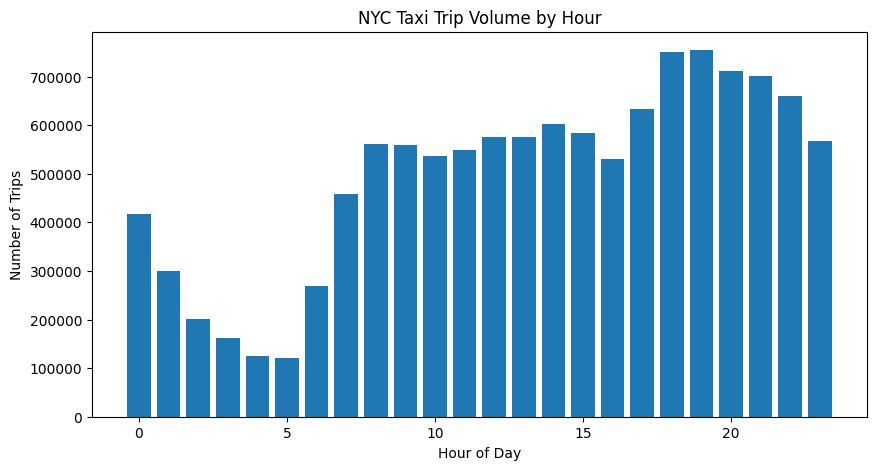

In [0]:
# Convert to Pandas for plotting (works on small aggregated data)
import matplotlib.pyplot as plt

peak_hours_pd = peak_hours.toPandas()
plt.figure(figsize=(10,5))
plt.bar(peak_hours_pd['pickup_hour'], peak_hours_pd['total_trips'])
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('NYC Taxi Trip Volume by Hour')
plt.show()